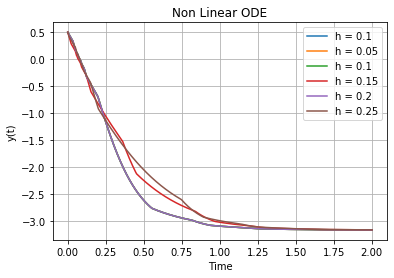

In [3]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
y0 = 0.5
t0 = 0
tf = 2
h_step = (0.1,0.05,.1,.15,.2,.25) 

def f_nonlinear(t, y):
    return y**2 - 10

def fprime(y):
    
    return 2 * y


def backward_euler_step(f, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  
    for _ in range(max_iter):
        g_val = y_next - y - h * f(t + h, y_next)
        g_prime_val = 1 - h * fprime(y_next)     
        if abs(g_prime_val) < tol:  
            break
        y_new = y_next - g_val / g_prime_val
        if abs(y_new - y_next) < tol:
            return y_new  
        y_next = y_new
    return y_next


def backward_euler_adaptive(f, y0, t0, tf, h_init, tol=1e-6, max_iter=50):
    t_values = [t0]
    y_values = [y0]
    h = h_init
    t = t0
    y = y0
    while t < tf:
        if t + h > tf: 
            h = tf - t
        
        y_full = backward_euler_step(f, y, t, h, tol, max_iter)
      
        h_half = h / 2
        y_half_1 = backward_euler_step(f, y, t, h_half, tol, max_iter)
        y_half_2 = backward_euler_step(f, y_half_1, t + h_half, h_half, tol, max_iter)
      
        error = abs(y_full - y_half_2)

        if error > tol:
            h /= 2  
            continue  
        elif error < tol / 2:
            h *= 2  

        t += h
        y = y_half_2
        t_values.append(t)
        y_values.append(y)
    return np.array(t_values), np.array(y_values)

for h in h_step:
    t_pts, y_pts = backward_euler_adaptive(f_nonlinear, y0, t0, tf, h)
    plt.plot(t_pts, y_pts, label=f'h = {h}')

plt.title("Non Linear ODE")
plt.xlabel("Time")
plt.ylabel("y(t)")
plt.grid(True)
plt.legend()
plt.show()

 